In [1]:
import pandas as pd

df_retail = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df_netflix = pd.read_csv('netflix_titles.csv')

In [2]:
df_retail.head()

df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df_retail.info()
df_netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-n

In [5]:
df_retail.isnull().sum()
df_netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df_retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df_retail = df_retail.dropna(subset=['Description'])

df_netflix['director'] = df_netflix['director'].fillna('Unknown')
df_netflix['cast'] = df_netflix['cast'].fillna('Unknown')
df_netflix['country'] = df_netflix['country'].fillna('Unknown')
df_netflix = df_netflix.dropna(subset=['date_added', 'rating', 'duration'])

In [8]:
print(df_retail.duplicated().sum())
print(df_netflix.duplicated().sum())

5268
0


In [9]:
df_retail = df_retail.drop_duplicates()

In [10]:
print(df_retail.duplicated().sum())
print(df_netflix.duplicated().sum())

0
0


In [11]:
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])
df_retail.columns = df_retail.columns.str.strip().str.lower()

df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'].str.strip())
df_netflix.columns = df_netflix.columns.str.strip().str.lower()

In [12]:
print(df_retail.columns.tolist())
print(df_retail['invoicedate'].dtype)
print(df_retail.duplicated().sum())

print(df_netflix.columns.tolist())
print(df_netflix['date_added'].dtype)

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']
datetime64[us]
0
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
datetime64[us]


In [13]:
print((df_retail['quantity'] < 0).sum())
print((df_retail['unitprice'] < 0).sum())

9725
2


In [14]:
print(df_retail[df_retail['quantity'] < 0]['invoiceno'].head())
print(df_retail[df_retail['unitprice'] < 0])

141    C536379
154    C536383
235    C536391
236    C536391
237    C536391
Name: invoiceno, dtype: str
       invoiceno stockcode      description  quantity         invoicedate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        unitprice  customerid         country  
299983  -11062.06         NaN  United Kingdom  
299984  -11062.06         NaN  United Kingdom  


In [15]:
df_retail = df_retail[df_retail['unitprice'] >= 0]

In [16]:
df_retail[['quantity', 'unitprice']].describe()

,quantity,unitprice
count,535185.000000,535185.000000
mean,9.671626,4.686598
std,219.059465,94.985568
min,-80995.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [17]:
df_netflix['release_year'].describe()

count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [18]:
df_retail.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64

In [19]:
df_retail['revenue'] = df_retail['quantity'] * df_retail['unitprice']
df_retail.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

country
United Kingdom    8189252.304
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: revenue, dtype: float64

In [20]:
df_retail['month'] = df_retail['invoicedate'].dt.to_period('M')
df_retail.groupby('month')['revenue'].sum()

month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: revenue, dtype: float64

In [21]:
df_retail.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)

customerid
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: revenue, dtype: float64

In [22]:
df_retail.groupby('description')['revenue'].sum().sort_values(ascending=False).head(10)

description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: revenue, dtype: float64

In [23]:
df_netflix['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [24]:
df_netflix['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [25]:
df_netflix['year_added'] = df_netflix['date_added'].dt.year
df_netflix['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [26]:
df_netflix['listed_in'].str.split(', ').explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [27]:
df_netflix['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

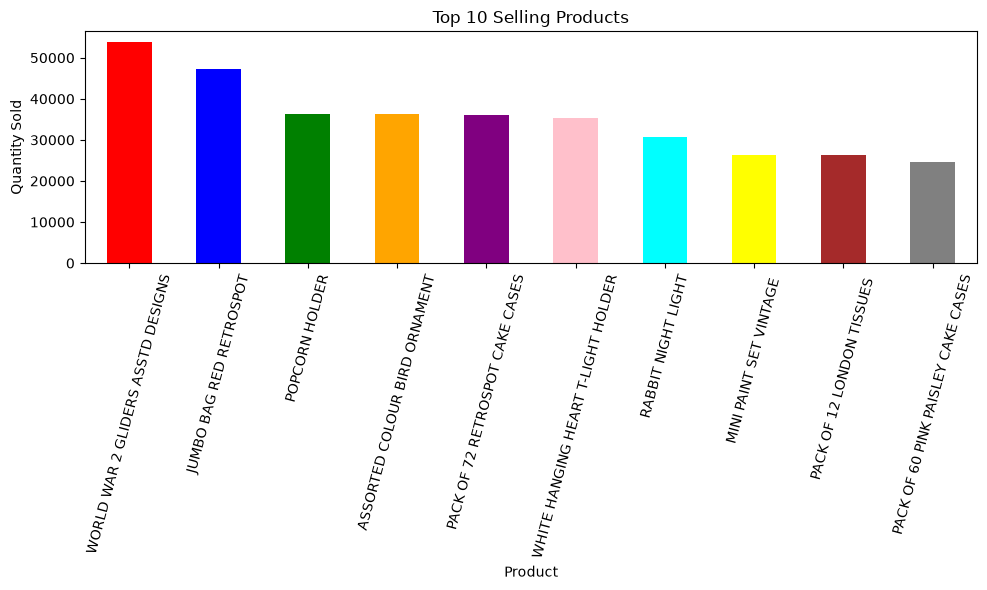

In [28]:
import matplotlib.pyplot as plt

top_products = df_retail.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar', color=['red','blue','green','orange','purple','pink','cyan','yellow','brown','gray'])
plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


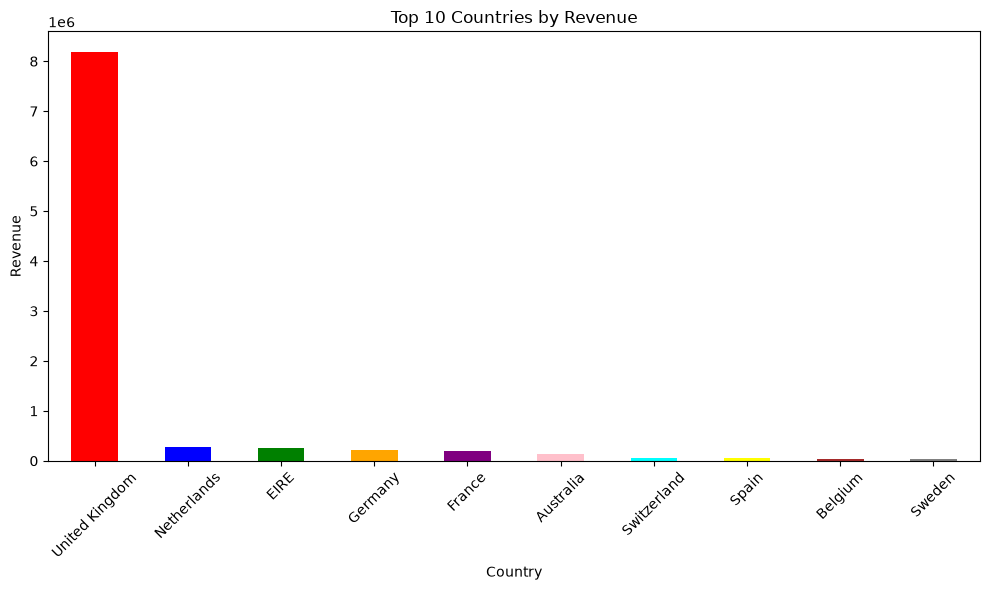

In [29]:
top_countries = df_retail.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color=['red','blue','green','orange','purple','pink','cyan','yellow','brown','gray'])
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

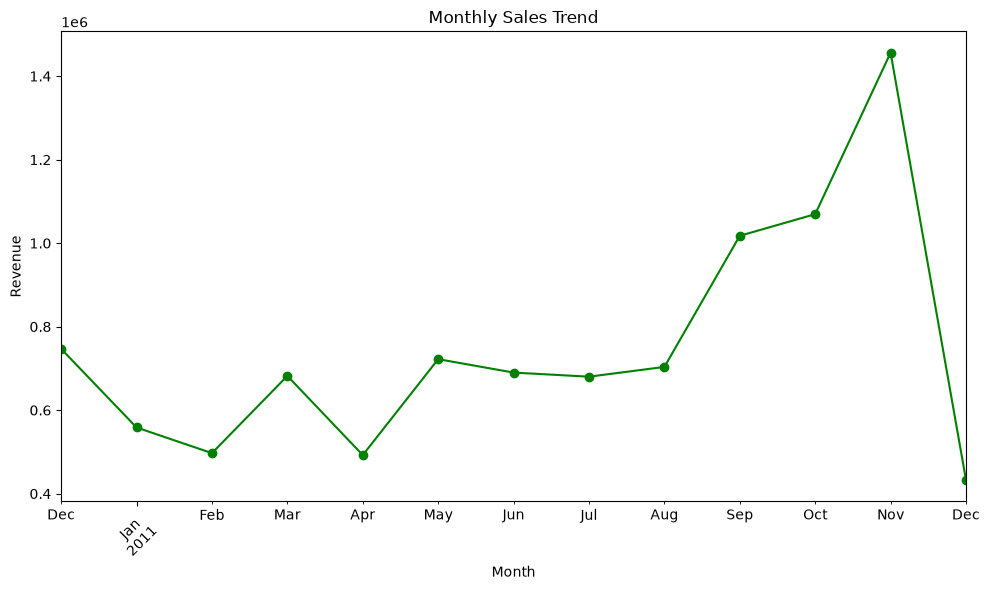

In [30]:
monthly_sales = df_retail.groupby('month')['revenue'].sum()

plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

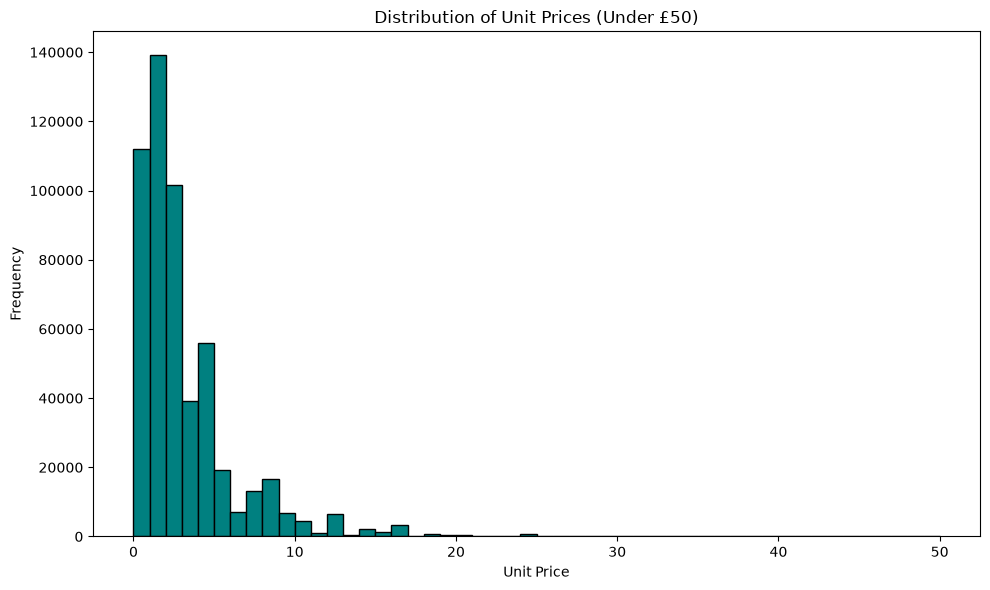

In [31]:
plt.figure(figsize=(10,6))
df_retail[df_retail['unitprice'] <= 50]['unitprice'].plot(kind='hist', bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Unit Prices (Under £50)')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

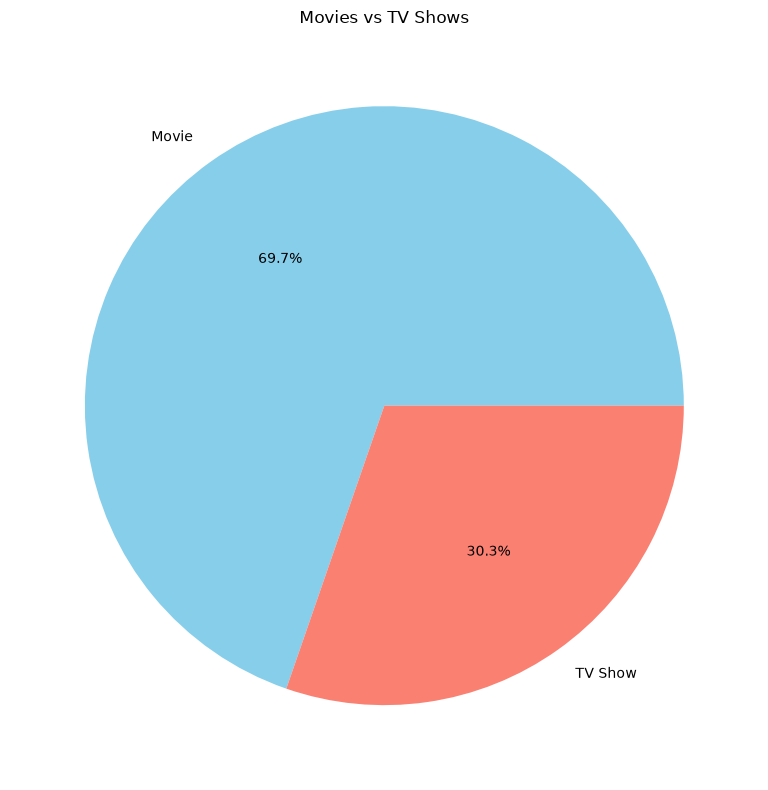

In [32]:
type_counts = df_netflix['type'].value_counts()

plt.figure(figsize=(8,8))
type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.tight_layout()
plt.show()

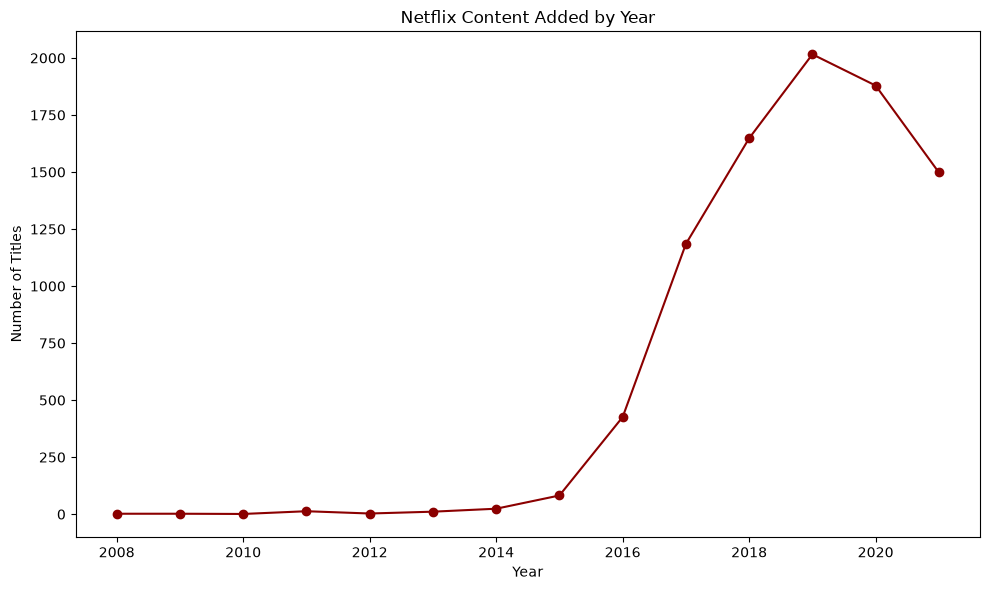

In [33]:
year_trend = df_netflix['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,6))
year_trend.plot(kind='line', marker='o', color='darkred')
plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

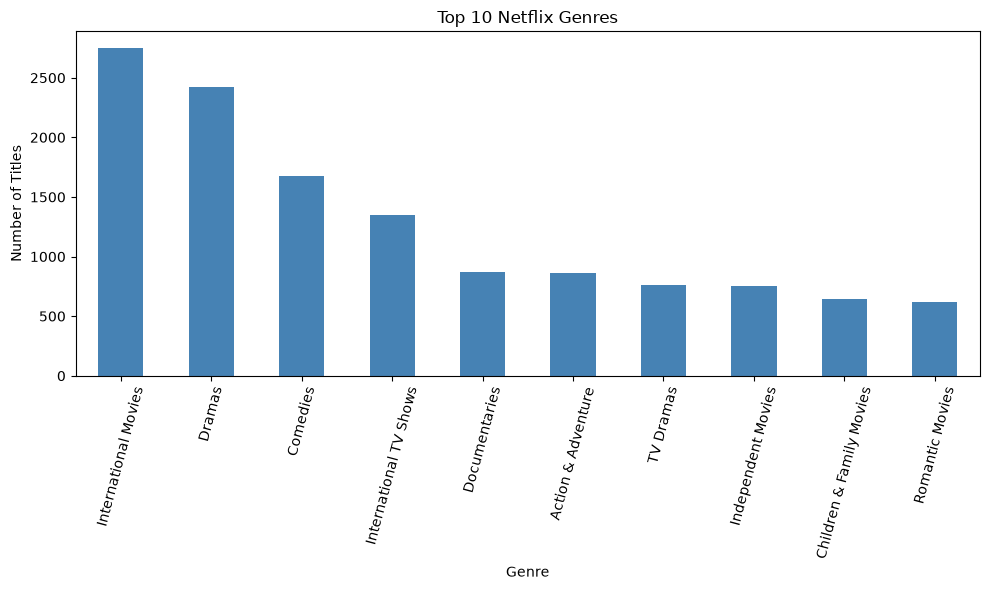

In [34]:
top_genres = df_netflix['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.plot(kind='bar', color='steelblue')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

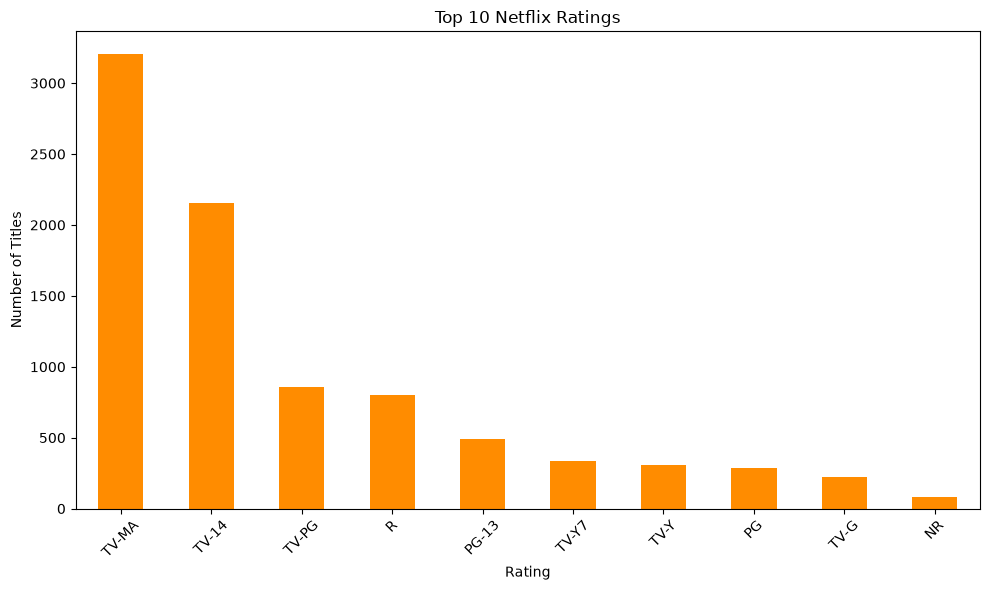

In [35]:
top_ratings = df_netflix['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_ratings.plot(kind='bar', color='darkorange')
plt.title('Top 10 Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df_retail.to_csv('cleaned_online_retail.csv', index=False)

In [37]:
df_netflix.to_csv('cleaned_netflix_titles.csv', index=False)